# 🟢 Fetching Weather data
from open-meteo api

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from fetcher import main

cities = {
    "New York":     {"latitude": 40.71, "longitude": -74.01},
    "Los Angeles":  {"latitude": 34.05, "longitude": -118.24},
    "Chicago":      {"latitude": 41.85, "longitude": -87.65},
    "Houston":      {"latitude": 29.76, "longitude": -95.37},
    "Phoenix":      {"latitude": 33.45, "longitude": -112.07},
    }

base_params = {
    "start_date": "2025-01-01",
    "end_date":   "2025-12-31",
    "daily":      "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone":   "America/New_York"
}

frames = []

notebook_dir = os.path.abspath("")
module_path = os.path.join(notebook_dir, "fetcher.py")

os.makedirs("fetched data", exist_ok=True)
os.makedirs("clean output", exist_ok=True)
os.makedirs("plots", exist_ok=True)

try:
    for city, coords in cities.items():
        params = {**base_params, **coords}
        df = main(params=params)
        df["city"] = city
        frames.append(df)        
        df_all = pd.concat(frames, ignore_index=True)
        df = df_all.copy()
        df.to_excel(os.path.join(notebook_dir, "fetched data", "weather_data.xlsx"), sheet_name="Weather Data", index=False)
except:
    print("Something went wrong.")


# 🟢 Data Cleaning

renaming columns for ease

In [2]:
df.rename({'temperature_2m_max': 'temp_max', 'temperature_2m_min': 'temp_min', 'precipitation_sum':'precipitation'}, axis=1, inplace=True)
# fixing datetime dtype
df['time'] = pd.to_datetime(df.time)

adding months column

In [3]:
df['month'] = df['time'].dt.month
col = df.pop('month')
df.insert(1, 'month', col)
df.head(3)

,time,month,temp_max,temp_min,precipitation,city
0,2025-01-01,1,10.9,3.9,4.5,New York
1,2025-01-02,1,5.4,0.3,0.0,New York
2,2025-01-03,1,3.2,-1.9,0.0,New York


adding temperature range and average temperature columns

In [4]:
df['avg_temp'] = (df.temp_max + df.temp_min) / 2
df['temp_range'] = df.temp_max - df.temp_min

relocating city column

In [5]:
col = df.pop('city')
df.insert(2, 'city', col)
df.head(3)

,time,month,city,temp_max,temp_min,precipitation,avg_temp,temp_range
0,2025-01-01,1,New York,10.9,3.9,4.5,7.40,7.0
1,2025-01-02,1,New York,5.4,0.3,0.0,2.85,5.1
2,2025-01-03,1,New York,3.2,-1.9,0.0,0.65,5.1


# 🟢 EDA (Exploratory Data Analysis)

random sample of 5 rows

In [6]:
df.sample(5)

,time,month,city,temp_max,temp_min,precipitation,avg_temp,temp_range
264,2025-09-22,9,New York,22.6,12.0,0.0,17.30,10.6
1281,2025-07-06,7,Houston,34.0,24.5,0.2,29.25,9.5
326,2025-11-23,11,New York,7.7,-0.9,0.0,3.40,8.6
664,2025-10-27,10,Los Angeles,23.0,13.8,0.0,18.40,9.2
361,2025-12-28,12,New York,1.0,-11.6,0.9,-5.30,12.6


checking index, missing values, dtypes, counts and columns

In [7]:
print(f"Shape of the DataFrame: \n{df.shape}\n\n")
df.info()

Shape of the DataFrame: 
(1825, 8)


<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           1825 non-null   datetime64[us]
 1   month          1825 non-null   int32         
 2   city           1825 non-null   str           
 3   temp_max       1825 non-null   float64       
 4   temp_min       1825 non-null   float64       
 5   precipitation  1825 non-null   float64       
 6   avg_temp       1825 non-null   float64       
 7   temp_range     1825 non-null   float64       
dtypes: datetime64[us](1), float64(5), int32(1), str(1)
memory usage: 107.1 KB


checking missing values count for each column

In [8]:
df.isna().sum()

time             0
month            0
city             0
temp_max         0
temp_min         0
precipitation    0
avg_temp         0
temp_range       0
dtype: int64

basic stats

In [9]:
df[['temp_max', 'temp_min', 'precipitation']].agg(['count', 'mean', 'min', 'max', 'median', 'std']).round(2)

,temp_max,temp_min,precipitation
count,1825.00,1825.00,1825.00
mean,22.84,12.81,2.47
min,-14.80,-21.90,0.00
max,46.90,33.90,87.40
median,24.60,14.00,0.00
std,11.01,9.67,7.20


statistical details of each month

In [10]:
gb = df.groupby('month')[['temp_max', 'temp_min', 'precipitation']].agg(['mean', 'median', 'min', 'max', 'std']).round(3)
gb

temp_max                            temp_min                            \
          mean median   min   max     std     mean median   min   max    std   
month                                                                          
1       10.100  12.90 -14.8  25.5   9.851    0.678   2.80 -21.0  16.5  7.854   
2       13.697  16.45 -14.3  30.2  10.917    4.027   7.25 -21.9  20.8  8.811   
3       18.690  19.60   0.6  36.0   7.757    7.946   8.20  -7.8  22.5  6.505   
4       22.321  23.95   3.6  37.5   7.992   11.633  11.60  -2.3  23.9  6.092   
5       25.999  26.00   8.8  39.8   7.508   15.816  14.90   5.7  26.1  5.432   
6       31.309  30.90  16.4  46.2   6.472   20.576  21.30   8.4  31.6  5.152   
7       32.769  31.50  20.9  46.8   5.239   22.784  23.00  15.0  33.9  4.496   
8       32.661  32.50  18.8  46.9   6.267   22.070  21.40  13.4  33.2  5.093   
9       29.817  29.65  18.2  41.2   5.493   19.944  19.05   9.9  31.5  4.305   
10      24.706  26.70   9.6  38.6   7.164   14.529  14.90   2.5  24.4  5.193   
11      18.367  18.60  -0.9  32.8   8.278    9.185   9.85  -4.8  21.3  6.125   
12      13.102  17.70 -13.3  27.6  10.049    4.003   6.40 -18.8  20.8  8.613   

      precipitation                            
               mean median  min   max     std  
month                                          
1             1.715    0.0  0.0  31.5   5.129  
2             2.107    0.0  0.0  41.9   6.228  
3             3.075    0.0  0.0  39.2   6.812  
4             1.726    0.0  0.0  38.6   4.758  
5             3.817    0.0  0.0  86.6  10.444  
6             2.763    0.0  0.0  39.9   6.723  
7             2.125    0.0  0.0  20.2   4.321  
8             1.425    0.0  0.0  22.6   3.646  
9             2.461    0.0  0.0  48.6   7.407  
10            2.690    0.0  0.0  87.4   9.855  
11            2.939    0.0  0.0  59.2   8.245  
12            2.797    0.0  0.0  67.0   8.861

Saving the clean dataset

In [ ]:
df.to_excel(os.path.join(notebook_dir, "clean output", "clean_weather_data.xlsx"), sheet_name="Clean")

### Data Visualisations for visual data inspection

In [12]:
# this function will save plots automatically, without needing to write the long code each time
def save_figure(name):
    plt.savefig(os.path.join(notebook_dir, f"plots/{name}.png"), dpi=300, bbox_inches="tight")

#### Spread of min and max temperature

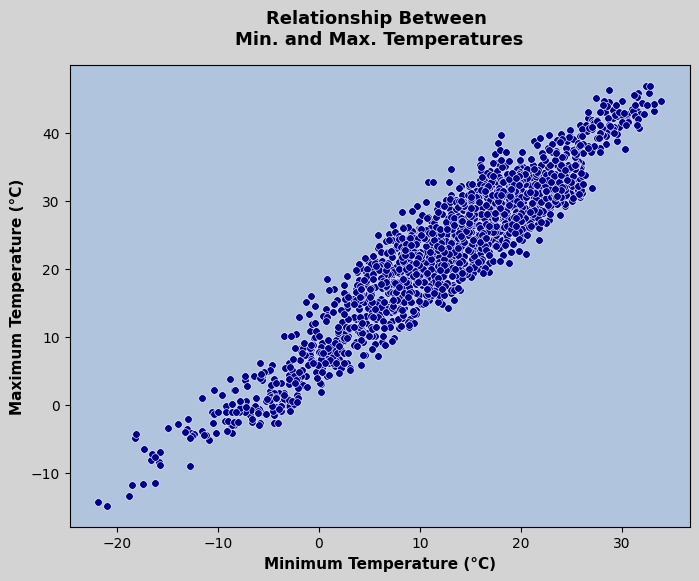

In [13]:
plt.figure(figsize=(8,6), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

sns.scatterplot(df, x='temp_min', y='temp_max', s=30, color='darkblue')
plt.xlabel("Minimum Temperature (°C)", fontsize=11, fontweight='bold')
plt.ylabel("Maximum Temperature (°C)", fontsize=11, fontweight='bold')
plt.title("Relationship Between \nMin. and Max. Temperatures", fontsize=13, pad=15, fontweight='bold')
save_figure("min_max_temp_relation")
plt.show()

#### Boxplot showing temperature spread of cities

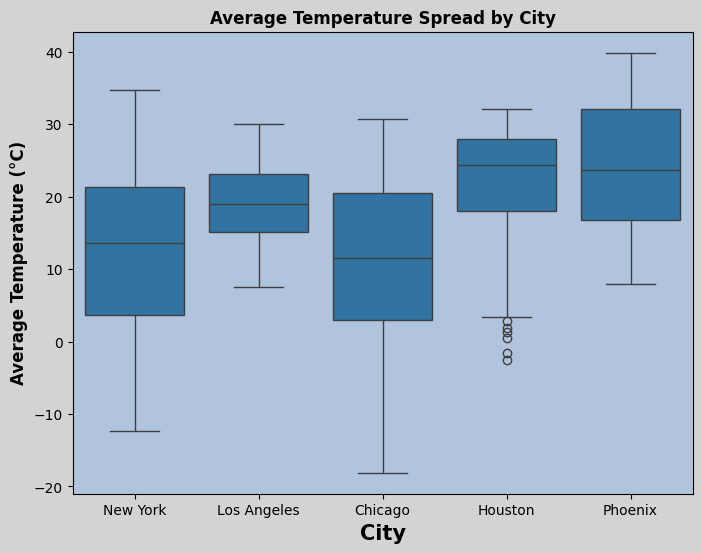

In [14]:
plt.figure(figsize=(8,6), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

sns.boxplot(data=df, x='city', y='avg_temp')
plt.xlabel("City", fontweight='bold', fontsize=15)
plt.ylabel("Average Temperature (°C)", fontweight='bold', fontsize=12)
plt.title("Average Temperature Spread by City", fontweight='bold')
save_figure("avg_temp_spread_by_city")
plt.show()

### Detecting Outliers

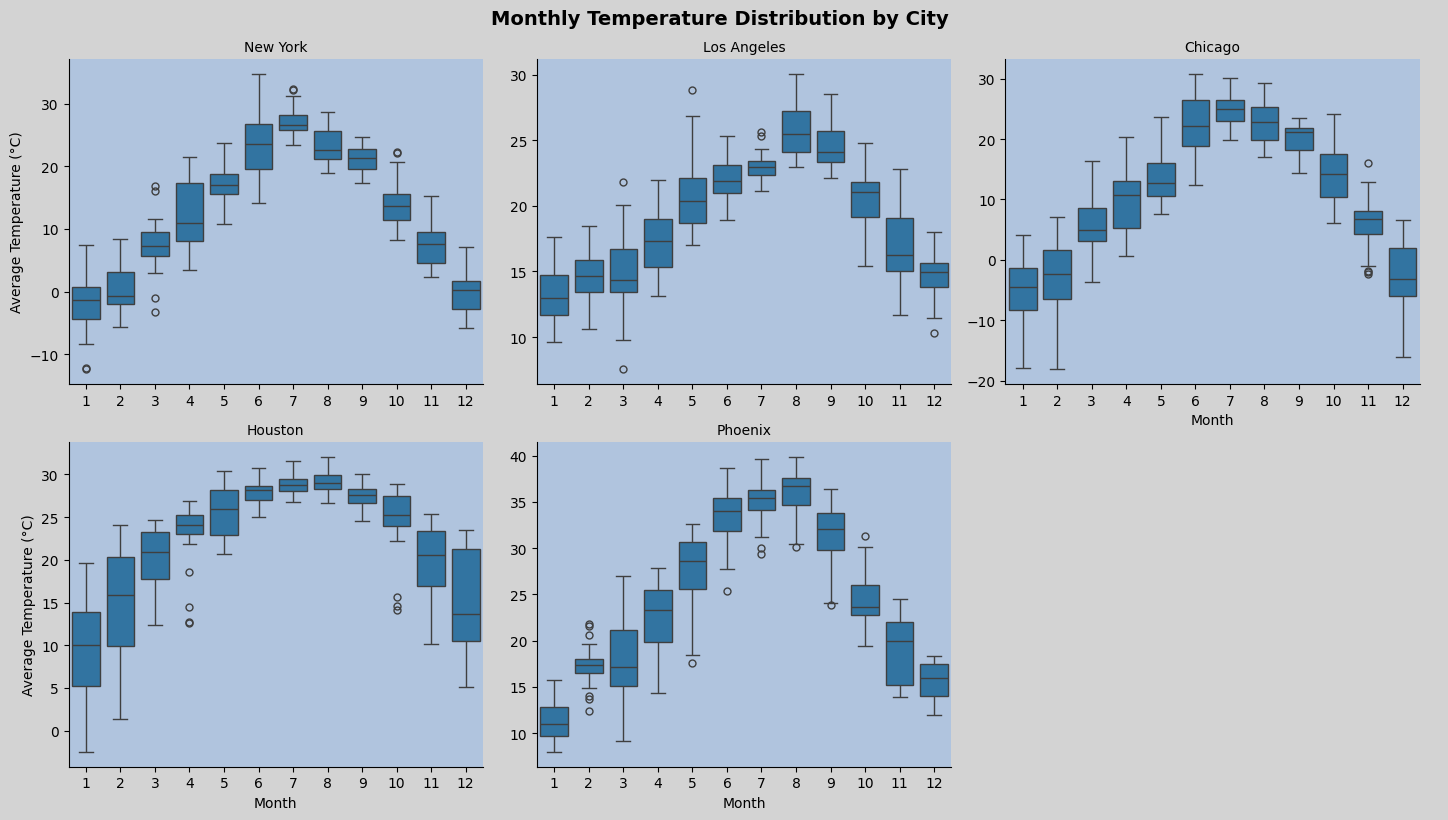

In [15]:
# Creates a grid where each column is a City, and X-axis shows Months
g = sns.catplot(
    data=df, 
    x='month', 
    y='avg_temp', 
    col='city', 
    kind='box',
    col_wrap=3,
    height=4, 
    aspect=1.2,
    sharex=False,
    sharey=False
)

g.figure.set_facecolor('lightgray')
for ax in g.axes.flat:
    ax.set_facecolor('lightsteelblue')

g.set_titles("{col_name}")
g.set_axis_labels("Month", "Average Temperature (°C)")
g.figure.suptitle("Monthly Temperature Distribution by City", fontweight='bold', fontsize=14, y=1.02)
save_figure("monthly_temp_distribution_by_city")
plt.show()

# 🟢 Data Analysis

## Temperature trends of each city throughout the year

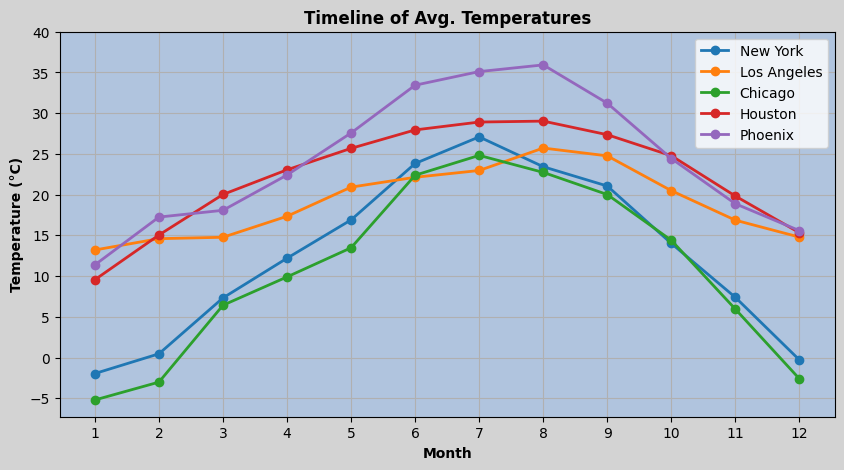

In [16]:
plt.figure(figsize=(10,5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

gb = df.groupby(['city', 'month'])['avg_temp'].mean()
for city in df.city.unique():
    mon = gb.loc[city]
    x = mon.index
    y = mon.values
    plt.plot(x, y, label=city, linewidth=2, marker='o')


plt.xticks(range(1,13))
plt.yticks([-5, 0, 5, 10, 15, 20, 25, 30, 35, 40])
plt.xlabel("Month", fontweight='bold')
plt.ylabel("Temperature (°C)", fontweight='bold')
plt.title('Timeline of Avg. Temperatures', fontweight='bold')
plt.grid(True)
plt.legend()
save_figure("avg_temp_timeline")
plt.show()

### Precipitation timeline of each city in whole year

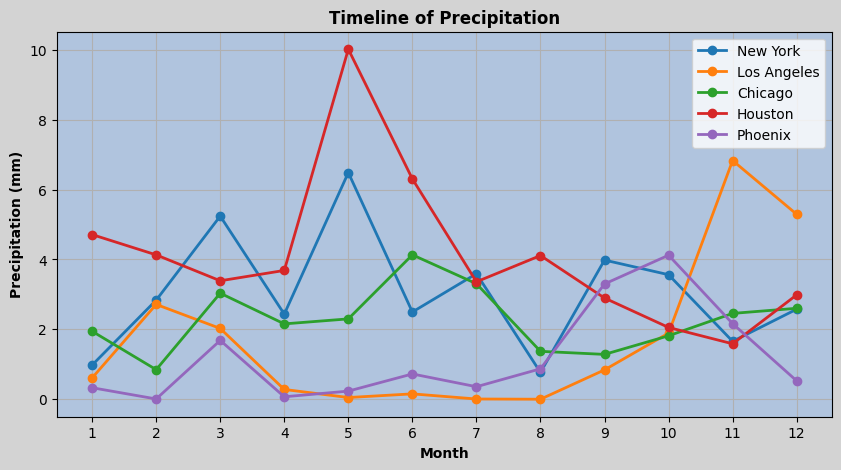

In [17]:
plt.figure(figsize=(10,5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

gb = df.groupby(['city', 'month'])['precipitation'].mean()
for city in df.city.unique():
    mon = gb.loc[city]
    x = mon.index
    y = mon.values
    plt.plot(x, y, label=city, linewidth=2, marker='o')


plt.xticks(range(1,13))
plt.xlabel("Month", fontweight='bold')
plt.ylabel("Precipitation (mm)", fontweight='bold')
plt.title('Timeline of Precipitation', fontweight='bold')
plt.grid(True)
plt.legend()
save_figure("avg_precipitation_timeline")
plt.show()

### Average Precipitation by City

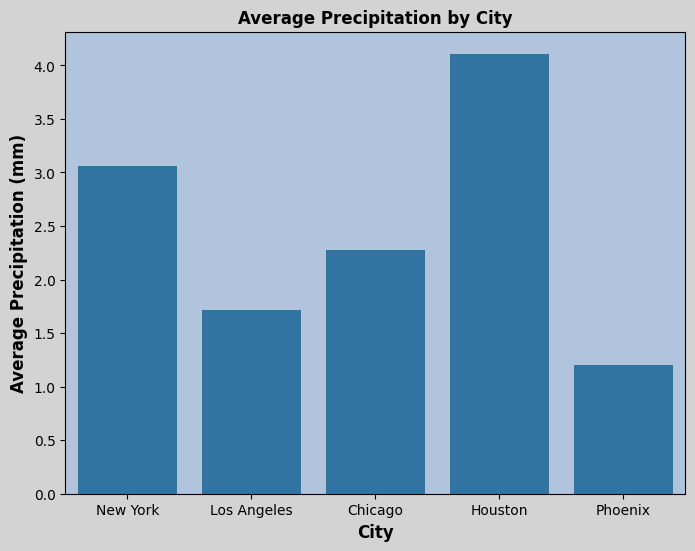

In [18]:
plt.figure(figsize=(8,6), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

sns.barplot(data=df, x='city', y='precipitation', estimator='mean', errorbar=None)
plt.xlabel("City", fontweight='bold', fontsize=12)
plt.ylabel("Average Precipitation (mm)", fontweight='bold', fontsize=12)
plt.title("Average Precipitation by City", fontweight='bold')
save_figure("avg_precipitation_by_city")
plt.show()

### City Comparisons

Hottest/coldest city per month

In [19]:
gb = df.groupby(['month', 'city'])['avg_temp'].mean()
temp_df = gb.unstack().round(2)
temp_df

# highest city/temp for each month
cities = temp_df.idxmax(axis=1)
temps = temp_df.max(axis=1)
hottest_cities = pd.concat([cities, temps], axis=1, keys=['City', 'Temperature'])
print("Hottest City each month with their temperatures")
print(hottest_cities)

#lowest city/temp for each month
cities = temp_df.idxmin(axis=1)
temps = temp_df.min(axis=1)
coldest_cities = pd.concat([cities, temps], axis=1, keys=['City', 'Temperature'])
print("\nColdest City each month with their temperatures")
print(coldest_cities)

Hottest City each month with their temperatures
              City  Temperature
month                          
1      Los Angeles        13.20
2          Phoenix        17.24
3          Houston        20.02
4          Houston        23.05
5          Phoenix        27.57
6          Phoenix        33.43
7          Phoenix        35.11
8          Phoenix        35.93
9          Phoenix        31.22
10         Houston        24.78
11         Houston        19.82
12         Phoenix        15.58

Coldest City each month with their temperatures
              City  Temperature
month                          
1          Chicago        -5.21
2          Chicago        -3.02
3          Chicago         6.42
4          Chicago         9.90
5          Chicago        13.47
6      Los Angeles        22.13
7      Los Angeles        22.96
8          Chicago        22.73
9          Chicago        20.01
10        New York        14.01
11         Chicago         5.94
12         Chicago        -2.62


### Heatmap showing all cities' avg monthly temperatures in a year

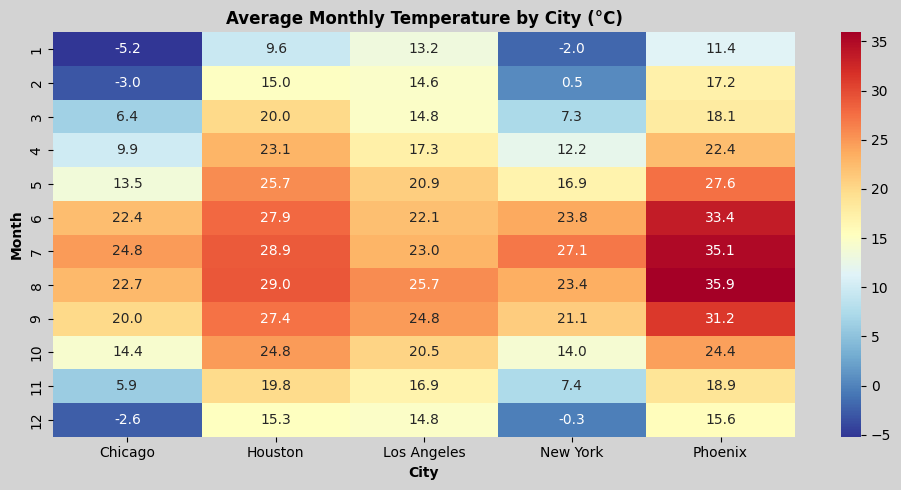

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('lightgray')

sns.heatmap(temp_df, annot=True, fmt=".1f", cmap="RdYlBu_r", ax=ax)
ax.set_title("Average Monthly Temperature by City (°C)", fontweight='bold')
plt.xlabel('City', fontweight='bold', fontsize=10)
plt.ylabel('Month', fontweight='bold', fontsize=10)
plt.tight_layout()
save_figure("heatmap_avg_monthly_temp")
plt.show()

### City with highest temp volatility (std of avg_temp)

city
Chicago        11.231295
Houston         7.228624
Los Angeles     4.691222
New York       10.390607
Phoenix         8.563983
Name: avg_temp, dtype: float64


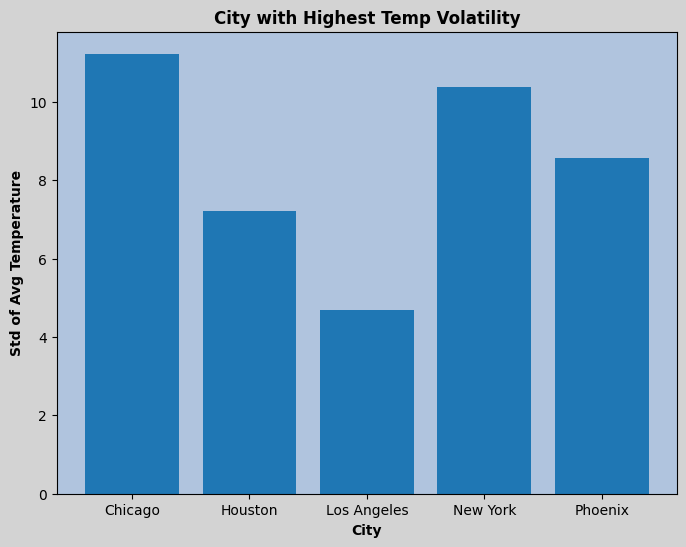

In [21]:
gb = df.groupby('city')['avg_temp'].std()
print(gb)

plt.figure(figsize=(8,6), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
plt.bar(gb.index, gb.values)
plt.xlabel('City', fontweight='bold')
plt.ylabel('Std of Avg Temperature', fontweight='bold')
plt.title('City with Highest Temp Volatility', fontweight='bold')
save_figure("temp_volatility_barplot")
plt.show()

#### Seasonal patterns: define winter/spring/summer/fall, compare across cities

In [22]:
seasons = {1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
           6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall',12:'Winter'}
df['season'] = df['month'].map(seasons)
df.groupby(['city','season'])['avg_temp'].mean().unstack().round(2)

season,Fall,Spring,Summer,Winter
city,,,,
Chicago,13.46,9.93,23.32,-3.64
Houston,23.99,22.91,28.63,13.25
Los Angeles,20.70,17.68,23.62,14.18
New York,14.15,12.13,24.79,-0.64
Phoenix,24.84,22.69,34.84,14.65


## Extreme Events

Hottest single day per city

In [23]:
# 1. Find the index of the maximum temperature for each city
idx = df.groupby('city')['temp_max'].idxmax()

# 2. Use those indices to extract the city, max temp, and date
result = df.loc[idx, ['city', 'temp_max', 'time']]

result

,city,temp_max,time
903,Chicago,35.6,2025-06-23
1304,Houston,37.5,2025-07-29
494,Los Angeles,39.6,2025-05-10
174,New York,40.4,2025-06-24
1678,Phoenix,46.9,2025-08-07


Days where precipitation > threshold (e.g. >20mm) — count per city

In [24]:
high_prec = df[df['precipitation'] > 20]
high_prec = high_prec[['city', 'precipitation', 'time']].reset_index(drop=True)
high_prec.groupby(['city', 'time'])['precipitation'].mean()

city         time      
Chicago      2025-01-31    31.5
             2025-04-02    20.1
             2025-05-20    21.9
             2025-06-04    32.4
             2025-06-18    39.9
             2025-07-11    20.2
             2025-10-19    20.6
             2025-12-28    41.2
Houston      2025-01-05    25.1
             2025-01-09    20.7
             2025-01-10    25.4
             2025-01-26    24.6
             2025-02-11    24.8
             2025-02-12    23.2
             2025-02-18    41.9
             2025-03-27    30.5
             2025-04-23    38.6
             2025-05-02    38.6
             2025-05-05    40.7
             2025-05-06    86.6
             2025-05-26    45.9
             2025-05-28    23.9
             2025-06-11    31.3
             2025-06-12    39.8
             2025-06-15    23.1
             2025-08-31    22.6
             2025-09-07    33.5
             2025-09-24    32.6
             2025-10-25    45.7
             2025-12-03    25.4
             202

Longest heatwave: consecutive days above e.g. 35°C



In [25]:
heatwave = df[df.temp_max > 35]
cons_hw = heatwave[['time', 'city', 'temp_max']].sort_values('time')

cons_hw['break'] = cons_hw['time'].diff().dt.days != 1
cons_hw['streak_id'] = cons_hw['break'].cumsum()

result = cons_hw.groupby(['city', 'streak_id'])['time'].count().reset_index(name='days')
print(result.groupby('city')['days'].max())

city
Chicago         1
Houston         1
Los Angeles     2
New York        2
Phoenix        15
Name: days, dtype: int64


## Further Key Questions

Which city has the most extreme seasons?

In [26]:
# Difference between hottest and coldest seasonal avg
seasonal = df.groupby(['city', 'season'])['avg_temp'].mean().unstack()
seasonal['range'] = seasonal.max(axis=1) - seasonal.min(axis=1)
print(seasonal['range'].round(2).sort_values(ascending=False))
print(f"{seasonal['range'].index[0]} has the most extreme seasons due to its high difference between hottest and coldest seasonal avg")

city
Chicago        26.96
New York       25.43
Phoenix        20.19
Houston        15.39
Los Angeles     9.44
Name: range, dtype: float64
Chicago has the most extreme seasons due to its high difference between hottest and coldest seasonal avg


Which month is statistically the harshest across all cities?

In [27]:
# Harshest = highest temp + highest precipitation combined (normalize both)
monthly = df.groupby('month').agg(avg_temp=('avg_temp','mean'), precip=('precipitation','mean'))
monthly['harsh_score'] = (
    (monthly['avg_temp'] - monthly['avg_temp'].min()) / (monthly['avg_temp'].max() - monthly['avg_temp'].min()) +
    (monthly['precip'] - monthly['precip'].min()) / (monthly['precip'].max() - monthly['precip'].min())
)
month_map = months = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December",
}
harshest_months = monthly['harsh_score'].sort_values(ascending=False)
print(f"{month_map[harshest_months.index[0]]} is the harshest month across all cities due to it's harsh score {harshest_months.values[0].round(3)} exceeding other months")
print(monthly['harsh_score'].round(3).sort_values(ascending=False))

May is the harshest month across all cities due to it's harsh score 1.693 exceeding other months
month
5     1.693
6     1.477
9     1.304
7     1.293
10    1.165
3     1.044
11    1.008
8     0.982
12    0.715
4     0.644
2     0.440
1     0.121
Name: harsh_score, dtype: float64


Which city is most "stable" weather-wise year-round?

In [28]:
# Lowest std of avg_temp = most stable
most_stable = df.groupby('city')['avg_temp'].std().sort_values()
print(f"{most_stable.index[0]} is the most stable city weather-wise.")
print(most_stable)

Los Angeles is the most stable city weather-wise.
city
Los Angeles     4.691222
Houston         7.228624
Phoenix         8.563983
New York       10.390607
Chicago        11.231295
Name: avg_temp, dtype: float64


Any city that breaks the seasonal pattern (Phoenix in winter vs summer)?

In [29]:
phoenix = df[df['city'] == 'Phoenix'].groupby('season')['avg_temp'].mean().round(2)
print(phoenix, "\n")
# Compare with others
all_cities = df.groupby(['city','season'])['avg_temp'].mean().round(2).unstack().T
print(all_cities)

season
Fall      24.84
Spring    22.69
Summer    34.84
Winter    14.65
Name: avg_temp, dtype: float64 

city    Chicago  Houston  Los Angeles  New York  Phoenix
season                                                  
Fall      13.46    23.99        20.70     14.15    24.84
Spring     9.93    22.91        17.68     12.13    22.69
Summer    23.32    28.63        23.62     24.79    34.84
Winter    -3.64    13.25        14.18     -0.64    14.65
